In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
covid_data=pd.read_csv('owid-covid-data.csv')

In [3]:
covid_data.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index
0,AFG,Asia,Afghanistan,2019-12-31,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
1,AFG,Asia,Afghanistan,2020-01-01,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
2,AFG,Asia,Afghanistan,2020-01-02,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
3,AFG,Asia,Afghanistan,2020-01-03,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
4,AFG,Asia,Afghanistan,2020-01-04,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498


In [4]:
covid_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44785 entries, 0 to 44784
Data columns (total 41 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   iso_code                         44521 non-null  object 
 1   continent                        44257 non-null  object 
 2   location                         44785 non-null  object 
 3   date                             44785 non-null  object 
 4   total_cases                      44182 non-null  float64
 5   new_cases                        43982 non-null  float64
 6   new_cases_smoothed               43200 non-null  float64
 7   total_deaths                     44182 non-null  float64
 8   new_deaths                       43982 non-null  float64
 9   new_deaths_smoothed              43200 non-null  float64
 10  total_cases_per_million          43918 non-null  float64
 11  new_cases_per_million            43918 non-null  float64
 12  new_cases_smoothed

In [5]:
covid_data.shape

(44785, 41)

In [6]:
covid_data = covid_data[['location','date','total_cases','new_cases','total_deaths']]

In [7]:
covid_data['date'] = pd.to_datetime(covid_data['date'])

In [9]:
covid_data.isnull().sum()

location          0
date              0
total_cases     603
new_cases       803
total_deaths    603
dtype: int64

In [10]:
covid_data = covid_data.dropna()

In [13]:
countries=['Nepal', 'India', 'United States']
covid_data=covid_data[covid_data['location'].isin(countries)]

In [14]:
covid_data.describe()

,date,total_cases,new_cases,total_deaths
count,778,7.780000e+02,778.000000,778.000000
mean,2020-05-11 14:57:41.182519296,9.479227e+05,15545.339332,31368.776350
min,2019-12-31 00:00:00,0.000000e+00,0.000000,0.000000
25%,2020-03-05 06:00:00,1.200000e+01,0.000000,0.000000
50%,2020-05-13 00:00:00,1.860650e+04,656.000000,97.000000
75%,2020-07-16 18:00:00,1.222571e+06,25532.000000,42284.750000
max,2020-09-19 00:00:00,6.724667e+06,97894.000000,198589.000000
std,NaN,1.688524e+06,23603.544962,54334.205877


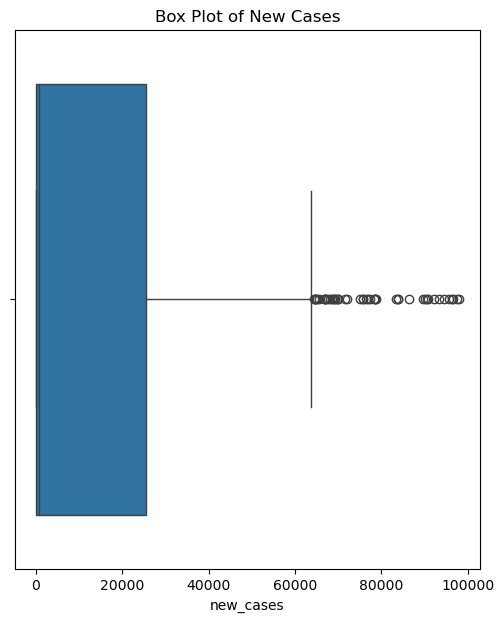

In [18]:
plt.figure(figsize=(6,7))
sns.boxplot(x=covid_data['new_cases'])
plt.title("Box Plot of New Cases")
plt.show()

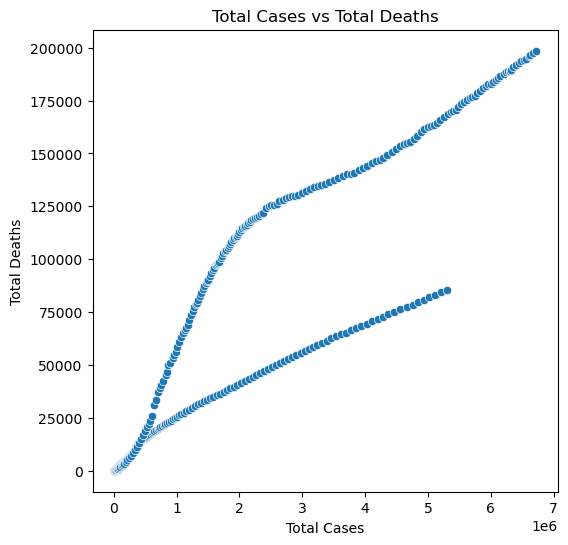

In [19]:
plt.figure(figsize=(6,6))
sns.scatterplot(x='total_cases',y='total_deaths',data=covid_data)
plt.title("Total Cases vs Total Deaths")
plt.xlabel("Total Cases")
plt.ylabel("Total Deaths")
plt.show()

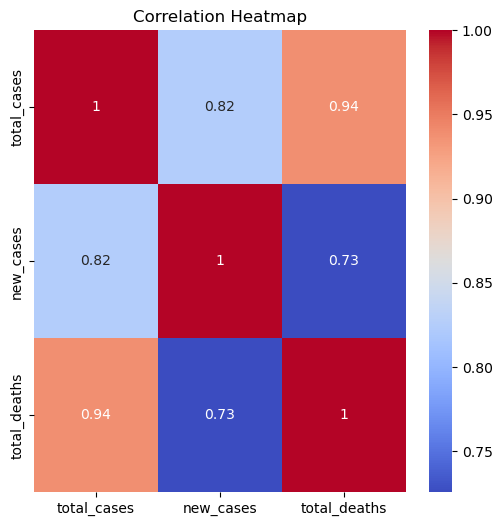

In [20]:
plt.figure(figsize=(6,6))
sns.heatmap(covid_data[['total_cases','new_cases','total_deaths']].corr(), 
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [23]:
summary = covid_data.describe()

In [24]:
summary.to_csv("summary_report.csv")

In [27]:
latest = covid_data.sort_values('date').groupby('location').tail(1)

In [28]:
latest = latest.sort_values('total_cases', ascending=False)
print(latest[['location','total_cases']])

            location  total_cases
42376  United States    6724667.0
18959          India    5308014.0
28655          Nepal      61593.0


In [29]:
covid_data.to_csv("cleaned_covid_data.csv", index=False)